In [1]:
from google.colab import files
uploaded = files.upload()
import xml.etree.ElementTree as ET
tree = ET.parse("540-ws-training.xml")
root = tree.getroot()

Saving 540-ws-training.xml to 540-ws-training.xml
Saving 544-ws-training.xml to 544-ws-training.xml
Saving 552-ws-training.xml to 552-ws-training.xml
Saving 567-ws-training.xml to 567-ws-training.xml
Saving 584-ws-training.xml to 584-ws-training.xml
Saving 596-ws-training.xml to 596-ws-training.xml


In [67]:
glucose = []

# Find glucose
glucose_level = root.find("glucose_level")

# pulling values for glucose
for event in glucose_level.findall("event"):
    ts = event.attrib.get("ts")
    value = event.attrib.get("value")

    if ts is not None and value is not None:
        glucose.append((ts, float(value)))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11947 entries, 0 to 11946
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   time     11947 non-null  datetime64[ns]
 1   glucose  11947 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 186.8 KB
                                time       glucose
count                          11947  11947.000000
mean   2027-06-10 16:55:11.180463872    137.098602
min              2027-05-19 11:36:29     40.000000
25%              2027-05-30 10:15:36     93.500000
50%              2027-06-10 13:19:29    127.000000
75%              2027-06-21 20:01:36    171.000000
max              2027-07-03 23:56:44    369.000000
std                              NaN     55.026251


<Axes: xlabel='time'>

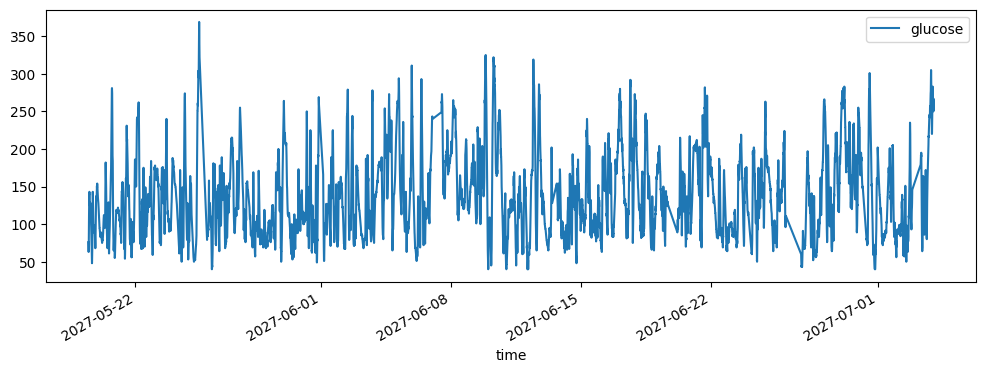

In [68]:
import pandas as pd
#turning data into dataframs
df_glucose = pd.DataFrame(glucose, columns=["time", "glucose"])

df_glucose["time"] = pd.to_datetime(
    df_glucose["time"],
    format="%d-%m-%Y %H:%M:%S"
)

df_glucose = df_glucose.sort_values("time")
#look at dataframe to make sure no null values
df_glucose.head()

df_glucose.info()
print(df_glucose.describe())
#plotting values to visualize variability
df_glucose.plot(x="time", y="glucose", figsize=(12,4))

<Axes: xlabel='time'>

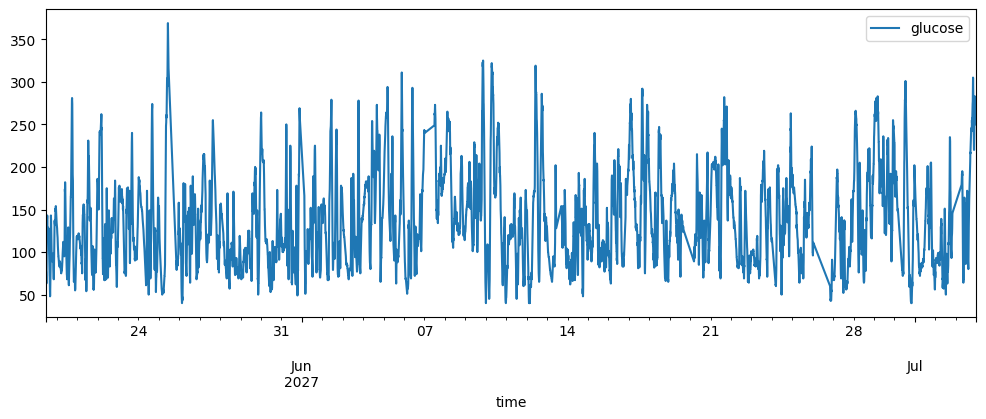

In [69]:
#setting intervals to 5 minutes
df_glucose = df_glucose.set_index("time")
df_glucose = df_glucose.resample("5min").mean()
df_glucose["glucose"] = df_glucose["glucose"].interpolate()
df_glucose.plot(figsize=(12,4))

In [192]:
import numpy as np

window_size = 12  # 1 hour bc 5x12=60 minutes
#turning time series into (X,y)
values = df_glucose["glucose"].values

X = []
y = []

for i in range(window_size, len(values)):
    X.append(values[i-window_size:i])    # x is = past glucose values
    y.append(values[i])                # y= next glucose value

X = np.array(X)
y = np.array(y)

print(X.shape)

(13097, 12)


In [193]:
from sklearn.linear_model import LinearRegression
n = len(X)

train_end = int(0.6 * n)
cal_end = int(0.8 * n) #note for report: this is called split conformal prediction (different from regular) - we are choosing it bc its significantly less expensive than full conformal prediction

X_train, y_train = X[:train_end], y[:train_end]
X_cal, y_cal = X[train_end:cal_end], y[train_end:cal_end]
X_test, y_test = X[cal_end:], y[cal_end:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_cal = model.predict(X_cal)

errors = np.abs(y_cal - y_pred_cal)

q = np.quantile(errors, 0.9)  # 90% interval

In [194]:
import numpy as np

# Predict on the held-out portion from your training file
y_pred_test_internal = model.predict(X_test)

lower_internal = y_pred_test_internal - q
upper_internal = y_pred_test_internal + q

coverage_internal = np.mean((y_test >= lower_internal) & (y_test <= upper_internal))
width_internal = np.mean(upper_internal - lower_internal)

print("Internal test coverage:", coverage_internal)
print("Internal average interval width:", width_internal)

Internal test coverage: 0.9122137404580153
Internal average interval width: 11.464570877312653


In [195]:
print(model)
q

LinearRegression()


np.float64(5.732285438656323)

In [10]:
#upload testing files
from google.colab import files
uploaded = files.upload()

Saving 540-ws-testing.xml to 540-ws-testing.xml
Saving 544-ws-testing.xml to 544-ws-testing.xml
Saving 552-ws-testing.xml to 552-ws-testing.xml
Saving 567-ws-testing.xml to 567-ws-testing.xml
Saving 584-ws-testing.xml to 584-ws-testing.xml
Saving 596-ws-testing.xml to 596-ws-testing.xml


In [196]:
# Imports
import os
import zipfile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [197]:
def load_glucose_file(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    glucose = []
    glucose_section = root.find("glucose_level")

    for event in glucose_section.findall("event"):
        ts = event.attrib.get("ts")
        val = event.attrib.get("value")

        if ts is not None and val is not None:
            glucose.append((ts, float(val)))

    df = pd.DataFrame(glucose, columns=["time", "glucose"])

    df["time"] = pd.to_datetime(
        df["time"],
        format="%d-%m-%Y %H:%M:%S"
    )

    df = df.sort_values("time")
    df = df.set_index("time")

    df = df.resample("5min").mean()
    df.loc[df["glucose"] <= 0, "glucose"] = np.nan
    df["glucose"] = df["glucose"].interpolate()
    df = df.dropna()

    return df

In [198]:
def make_windows(df, window_size=12):
    values = df["glucose"].values
    X = []
    y = []

    for i in range(window_size , len(values)):
        X.append(values[i-window_size:i])
        y.append(values[i])

    return np.array(X), np.array(y)

In [199]:
window_size = 12
test_folder = "."

X_test_all = []
y_test_all = []

for file_name in os.listdir(test_folder):
    if file_name.endswith(".xml") and "testing" in file_name and "(" not in file_name: #only runs for testing data
        file_path = os.path.join(test_folder, file_name)
#loading data for one patient
        df_patient = load_glucose_file(file_path)
        #convert into supervised learning
        X_patient, y_patient = make_windows(df_patient, window_size)
#store patient results
        X_test_all.append(X_patient)
        y_test_all.append(y_patient)

        print(file_name, "processed:", X_patient.shape, y_patient.shape)
#combine all patients into 1 dataset
X_test_all = np.vstack(X_test_all)
y_test_all = np.concatenate(y_test_all)

552-ws-testing.xml processed: (3938, 12) (3938,)
544-ws-testing.xml processed: (3124, 12) (3124,)
540-ws-testing.xml processed: (3054, 12) (3054,)
596-ws-testing.xml processed: (2991, 12) (2991,)
567-ws-testing.xml processed: (2859, 12) (2859,)
584-ws-testing.xml processed: (2983, 12) (2983,)


In [200]:
y_pred_final = model.predict(X_test_all)

lower = y_pred_final - q
upper = y_pred_final + q

In [201]:
#see final test coverage and average interval width after conformal prediction
coverage = np.mean((y_test_all >= lower) & (y_test_all <= upper))
width = np.mean(upper - lower)

print("Final test coverage:", coverage)
print("Final average interval width:", width) #width doesnt change and it isn't going to, because width is 2xq and q is the same since we havent updated the model at all

Final test coverage: 0.9283339490210565
Final average interval width: 11.464570877312656


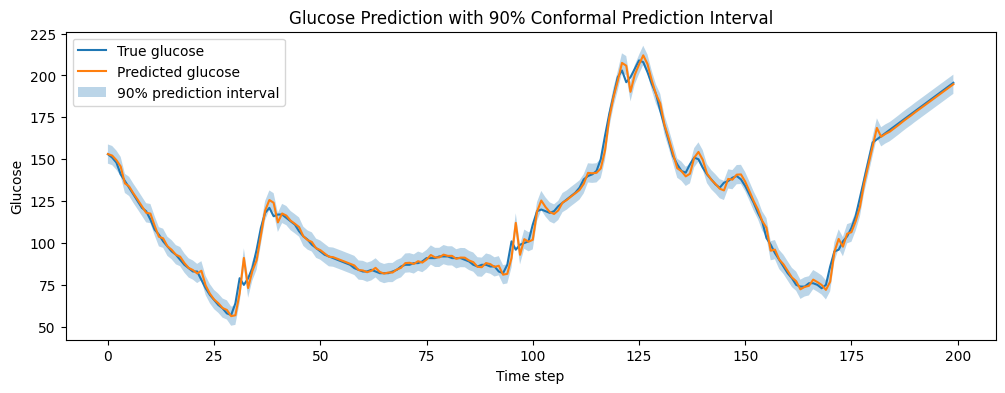

In [202]:
import matplotlib.pyplot as plt

num_points = 200 #number of timestamps to visualize
#plot glucose prediction intervals
plt.figure(figsize=(12,4))
plt.plot(y_test_all[:num_points], label="True glucose")
plt.plot(y_pred_final[:num_points], label="Predicted glucose")

plt.fill_between(
    range(num_points),
    lower[:num_points],
    upper[:num_points],
    alpha=0.3,
    label="90% prediction interval"
)

plt.legend()
plt.title("Glucose Prediction with 90% Conformal Prediction Interval")
plt.xlabel("Time step")
plt.ylabel("Glucose")
plt.show()

In [19]:
#upload all patient training files
from google.colab import files
uploaded = files.upload()

Saving 540-ws-training.xml to 540-ws-training (1).xml
Saving 544-ws-training.xml to 544-ws-training (1).xml
Saving 552-ws-training.xml to 552-ws-training (1).xml
Saving 567-ws-training.xml to 567-ws-training (1).xml
Saving 584-ws-training.xml to 584-ws-training (1).xml
Saving 596-ws-training.xml to 596-ws-training (1).xml


In [203]:
# Now training and testing on all patients and not just one

window_size = 12
train_folder = "."

X_train_all = []
y_train_all = []

for file_name in os.listdir(train_folder):
    if file_name.endswith(".xml") and "training" in file_name and "(" not in file_name:
        file_path = os.path.join(train_folder, file_name)

        df_patient = load_glucose_file(file_path)
        X_patient, y_patient = make_windows(df_patient, window_size)

        X_train_all.append(X_patient)
        y_train_all.append(y_patient)

        print(file_name, "processed:", X_patient.shape, y_patient.shape)

X_train_all = np.vstack(X_train_all)
y_train_all = np.concatenate(y_train_all)

print("Final X_train_all shape:", X_train_all.shape)
print("Final y_train_all shape:", y_train_all.shape)

584-ws-training.xml processed: (13236, 12) (13236,)
596-ws-training.xml processed: (13617, 12) (13617,)
540-ws-training.xml processed: (13097, 12) (13097,)
567-ws-training.xml processed: (13524, 12) (13524,)
544-ws-training.xml processed: (12660, 12) (12660,)
552-ws-training.xml processed: (11085, 12) (11085,)
Final X_train_all shape: (77219, 12)
Final y_train_all shape: (77219,)


In [204]:

import math
n = len(X_train_all)

train_end = int(0.75 * n)

X_train_final, y_train_final = X_train_all[:train_end], y_train_all[:train_end]
X_cal, y_cal = X_train_all[train_end:], y_train_all[train_end:]


print("X_train_final:", X_train_final.shape)
print("X_cal:", X_cal.shape)

X_train_final: (57914, 12)
X_cal: (19305, 12)


In [205]:
model = LinearRegression()
model.fit(X_train_final, y_train_final)

y_pred_cal = model.predict(X_cal)

y_pred_cal_glucose_only = y_pred_cal

errors = np.abs(y_cal - y_pred_cal)

k = len(errors)
q_needed = math.ceil(.9*(k+1))/k
q_g_only = np.quantile(errors, min(q_needed, 1.0), method='higher')

print("New q:", q_g_only)
print("New interval width:", 2*q_g_only) #if we are calculating the width as 2q here then it should be calculated the same way above for consistency

New q: 5.2203801022026255
New interval width: 10.440760204405251


In [206]:
y_pred_final = model.predict(X_test_all)

lower = y_pred_final - q_g_only
upper = y_pred_final + q_g_only

coverage_g_only = np.mean((y_test_all >= lower) & (y_test_all <= upper))
width_g_only = np.mean(upper - lower)

print("Final test coverage:", coverage_g_only)
print("Final average interval width:", width_g_only)

Final test coverage: 0.9126075254630851
Final average interval width: 10.440760204405251


In [207]:
# Inspect one training file to see available sections
tree = ET.parse("540-ws-training.xml")
root = tree.getroot()

for child in root:
    print(child.tag)

glucose_level
finger_stick
basal
temp_basal
bolus
meal
sleep
work
stressors
hypo_event
illness
exercise
basis_heart_rate
basis_gsr
basis_skin_temperature
basis_air_temperature
basis_steps
basis_sleep
acceleration


In [219]:
def load_glucose_carbs_insulin_file(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

#extract glucose
    glucose = []
    glucose_section = root.find("glucose_level")

    for event in glucose_section.findall("event"):
        ts = event.attrib.get("ts")
        val = event.attrib.get("value")

        if ts is not None and val is not None:
            glucose.append((ts, float(val)))

    df_glucose = pd.DataFrame(glucose, columns=["time", "glucose"])
    df_glucose["time"] = pd.to_datetime(df_glucose["time"], format="%d-%m-%Y %H:%M:%S")
    df_glucose = df_glucose.sort_values("time").set_index("time")
#extract carbs and meals
    carbs = []
    meal_section = root.find("meal")

    if meal_section is not None:
        for event in meal_section.findall("event"):
            ts = event.attrib.get("ts") or event.attrib.get("ts_begin")

            # dif files may call carbs "carbs" or "value"
            val = event.attrib.get("carbs")
            if val is None:
                val = event.attrib.get("value")

            if ts is not None and val is not None:
                carbs.append((ts, float(val)))

    df_carbs = pd.DataFrame(carbs, columns=["time", "carbs"])

    if len(df_carbs) > 0:
        df_carbs["time"] = pd.to_datetime(df_carbs["time"], format="%d-%m-%Y %H:%M:%S")
        df_carbs = df_carbs.sort_values("time").set_index("time")
    else:
        df_carbs = pd.DataFrame(columns=["carbs"])
        df_carbs.index = pd.to_datetime([])
#extract insulin/bolus
    insulin = []

    bolus_section = root.find("bolus")

    if bolus_section is not None:
        for event in bolus_section.findall("event"):
            ts = event.attrib.get("ts") or event.attrib.get("ts_begin")

            # Different files may call insulin "dose", "value", or "normal"
            val = event.attrib.get("dose")
            if val is None:
                val = event.attrib.get("value")
            if val is None:
                val = event.attrib.get("normal")

            if ts is not None and val is not None:
                insulin.append((ts, float(val)))

    df_insulin = pd.DataFrame(insulin, columns=["time", "insulin"])

    if len(df_insulin) > 0:
        df_insulin["time"] = pd.to_datetime(df_insulin["time"], format="%d-%m-%Y %H:%M:%S")
        df_insulin = df_insulin.sort_values("time").set_index("time")
    else:
        df_insulin = pd.DataFrame(columns=["insulin"])
        df_insulin.index = pd.to_datetime([])
#make everything even intervals of 5 mins
    df_glucose = df_glucose.resample("5min").mean()
    df_carbs = df_carbs.resample("5min").sum()
    df_insulin = df_insulin.resample("5min").sum()
#merge into 1 dataframe
    df = df_glucose.join(df_carbs, how="left")
    df = df.join(df_insulin, how="left")
#clean missing values
    df.loc[df["glucose"] <= 0, "glucose"] = np.nan
    df["glucose"] = df["glucose"].interpolate()

    # missing values for carbs or insulin just means that there were none for that time because they are event based
    df["carbs"] = df["carbs"].fillna(0)
    df["insulin"] = df["insulin"].fillna(0)

    #adjust carb and insulin values to follow exponential decay
    df["carbs"] = df["carbs"].ewm(halflife=6).mean()
    df["insulin"] = df["insulin"].ewm(halflife=10).mean()

    df['carbs'] = df['carbs'] *10
    df['insulin'] = df['insulin'] *100

    df = df.dropna()
    df = df[['glucose', 'carbs', 'insulin']]

    return df

In [220]:
def make_windows_multifeature_original(df, window_size=12):
    features = df[["glucose", "carbs", "insulin"]].values
    target = df["glucose"].values
    X = []
    y = []

    for i in range(window_size, len(df)):
      #full window for glucose only
      glucose_window = features[i-window_size:i, 0]

      latest_carbs = [features[i-1, 1]]
      latest_insulin = [features[i-1, 2]]

      combined_row = np.concatenate([glucose_window, latest_carbs, latest_insulin])

      X.append(combined_row)
      y.append(target[i])

    return np.array(X), np.array(y)

In [221]:
def make_windows_multifeature(df, window_size=12):
    features = df[["glucose", "carbs", "insulin"]].values
    target = df["glucose"].values
    X = []
    y = []

    for i in range(window_size, len(df)):
      glucose_window = features[i-window_size:i, 0]


      latest_carbs = features[i-1, 1]
      latest_insulin = features[i-1, 2]

      combined_row = np.hstack([glucose_window, latest_carbs, latest_insulin])

      X.append(combined_row)
      y.append(target[i])

    return np.array(X), np.array(y)

In [222]:
from sklearn.preprocessing import StandardScaler
window_size = 12
train_folder = "."

X_train_all = []
y_train_all = []

for file_name in os.listdir(train_folder):
    if file_name.endswith(".xml") and "training" in file_name and "(" not in file_name:
        file_path = os.path.join(train_folder, file_name)

        df_patient = load_glucose_carbs_insulin_file(file_path)
        X_patient, y_patient = make_windows_multifeature(df_patient, window_size)

        X_train_all.append(X_patient)
        y_train_all.append(y_patient)

        print(file_name, "processed:", X_patient.shape, y_patient.shape)

X_train_all = np.vstack(X_train_all)
y_train_all = np.concatenate(y_train_all)


print("Final X_train_all shape:", X_train_all.shape)
print("Final y_train_all shape:", y_train_all.shape)

584-ws-training.xml processed: (13236, 14) (13236,)
596-ws-training.xml processed: (13617, 14) (13617,)
540-ws-training.xml processed: (13097, 14) (13097,)
567-ws-training.xml processed: (13524, 14) (13524,)
544-ws-training.xml processed: (12660, 14) (12660,)
552-ws-training.xml processed: (11085, 14) (11085,)
Final X_train_all shape: (77219, 14)
Final y_train_all shape: (77219,)


In [223]:
import math
n = len(X_train_all)

train_end = int(0.75 * n)

X_train_final, y_train_final = X_train_all[:train_end], y_train_all[:train_end]
X_cal, y_cal = X_train_all[train_end:], y_train_all[train_end:]



model_features = LinearRegression()
model_features.fit(X_train_final, y_train_final)

y_pred_cal = model_features.predict(X_cal)

errors = np.abs(y_cal - y_pred_cal)
#calculating q
k = len(errors)
q_needed = math.ceil(.9*(k+1))/k

q_features = np.quantile(errors, min(q_needed, 1.0), method='higher')

print("New q with carbs + insulin:", q_features)
print("New interval width:", 2*q_features)


New q with carbs + insulin: 5.179103764968573
New interval width: 10.358207529937147


In [224]:
X_test_all_features = []
y_test_all_features = []

for file_name in os.listdir("."):
    if file_name.endswith(".xml") and "testing" in file_name and "(" not in file_name:
        file_path = os.path.join(".", file_name)

        df_patient = load_glucose_carbs_insulin_file(file_path)
        X_patient, y_patient = make_windows_multifeature(df_patient, window_size)

        X_test_all_features.append(X_patient)
        y_test_all_features.append(y_patient)

        print(file_name, "processed:", X_patient.shape, y_patient.shape)

X_test_all_features = np.vstack(X_test_all_features)
y_test_all_features = np.concatenate(y_test_all_features)

X_test_linear_features = X_test_all_features.copy()
y_test_linear_features = y_test_all_features.copy()

print("Final X_test_all_features shape:", X_test_all_features.shape)
print("Final y_test_all_features shape:", y_test_all_features.shape)

552-ws-testing.xml processed: (3938, 14) (3938,)
544-ws-testing.xml processed: (3124, 14) (3124,)
540-ws-testing.xml processed: (3054, 14) (3054,)
596-ws-testing.xml processed: (2991, 14) (2991,)
567-ws-testing.xml processed: (2859, 14) (2859,)
584-ws-testing.xml processed: (2983, 14) (2983,)
Final X_test_all_features shape: (18949, 14)
Final y_test_all_features shape: (18949,)


/tmp/ipykernel_1726/3355220960.py:82: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["carbs"] = df["carbs"].fillna(0)


In [225]:
y_pred_features = model_features.predict(X_test_all_features)

lower_features = y_pred_features - q_features
upper_features = y_pred_features + q_features

coverage_features = np.mean(
    (y_test_all_features >= lower_features) &
    (y_test_all_features <= upper_features)
)

width_features = np.mean(upper_features - lower_features)

print("Final test coverage with carbs + insulin:", coverage_features)
print("Final average interval width with carbs + insulin:", width_features)

Final test coverage with carbs + insulin: 0.911868700195261
Final average interval width with carbs + insulin: 10.358207529937143


In [226]:
model_features.coef_
print("Shape of y_cal:", y_cal.shape)
print("Shape of y_pred_cal:", y_pred_cal.shape)
print("Max error:", np.max(errors))

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 1. Create a DataFrame of your features
# Assuming your columns are ordered: Glucose(12), Carbs(12), Insulin(12)
feature_names = [f'G_lag_{i}' for i in range(12)] + \
                [f'C_lag_{i}' for i in range(1)] + \
                [f'I_lag_{i}' for i in range(1)]
vif_df = pd.DataFrame()
vif_df["Feature"] = feature_names

# 2. Calculate VIF for each feature
# Note: This takes a second to run because it's doing 36 regressions
vif_df["VIF"] = [variance_inflation_factor(X_train_final, i) for i in range(X_train_final.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))

Shape of y_cal: (19305,)
Shape of y_pred_cal: (19305,)
Max error: 67.79955037807093
     Feature          VIF
5    G_lag_5  7247.045124
4    G_lag_4  7246.420509
3    G_lag_3  7242.921601
6    G_lag_6  7240.780869
7    G_lag_7  7220.277323
2    G_lag_2  7205.982296
8    G_lag_8  7199.955309
9    G_lag_9  7162.311310
1    G_lag_1  6200.750987
10  G_lag_10  6173.164398
0    G_lag_0  1604.350501
11  G_lag_11  1603.115017
13   I_lag_0     1.563244
12   C_lag_0     1.135806


In [227]:
model_features.coef_

array([-1.04502489e-02,  1.24187979e-02, -5.41475180e-03,  3.32786177e-03,
       -4.65701537e-03,  1.36287120e-03, -2.60181537e-02,  1.65477188e-02,
       -4.30646347e-02,  1.48345111e-01, -7.78966455e-01,  1.67822986e+00,
        1.46575374e-02, -1.17089824e-04])

In [229]:
#compare models coverage and interval width in a df
results = pd.DataFrame({
    "Model": ["Glucose only", "Glucose + Carbs + Insulin"],
    "Coverage": [coverage_g_only, coverage_features],
    "Interval Width": [width_g_only, width_features]
})

print(results)

                       Model  Coverage  Interval Width
0               Glucose only  0.912608       10.440760
1  Glucose + Carbs + Insulin  0.911869       10.358208


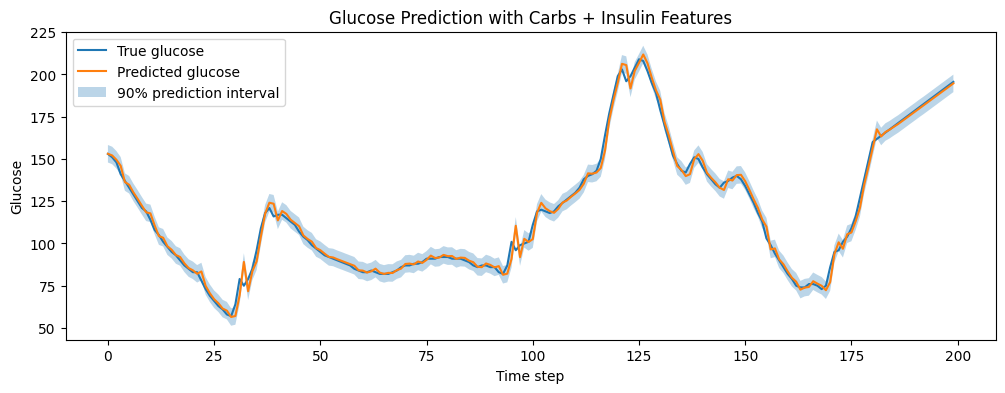

In [230]:
num_points = 200
#plot glucose prediction with carbs and insulin the same way as earlier
plt.figure(figsize=(12,4))

plt.plot(y_test_all_features[:num_points], label="True glucose")
plt.plot(y_pred_features[:num_points], label="Predicted glucose")

plt.fill_between(
    range(num_points),
    lower_features[:num_points],
    upper_features[:num_points],
    alpha=0.3,
    label="90% prediction interval"
)

plt.legend()
plt.title("Glucose Prediction with Carbs + Insulin Features")
plt.xlabel("Time step")
plt.ylabel("Glucose")
plt.show()

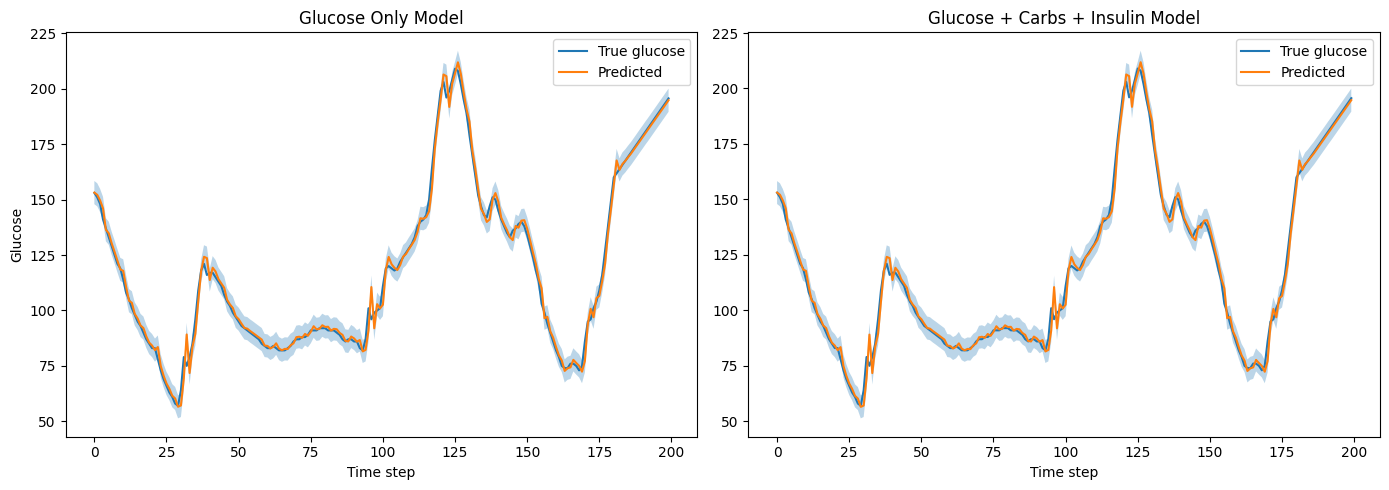

In [231]:
num_points = 200

plt.figure(figsize=(14,5))

# Glucose only plot
plt.subplot(1,2,1)

plt.plot(y_test_all[:num_points], label="True glucose")
plt.plot(y_pred_final[:num_points], label="Predicted")

plt.fill_between(
    range(num_points),
    lower[:num_points],
    upper[:num_points],
    alpha=0.3
)

plt.title("Glucose Only Model")
plt.xlabel("Time step")
plt.ylabel("Glucose")
plt.legend()

# Carbs + insulin plot
plt.subplot(1,2,2)

plt.plot(y_test_all_features[:num_points], label="True glucose")
plt.plot(y_pred_features[:num_points], label="Predicted")

plt.fill_between(
    range(num_points),
    lower_features[:num_points],
    upper_features[:num_points],
    alpha=0.3
)

plt.title("Glucose + Carbs + Insulin Model")
plt.xlabel("Time step")
plt.legend()

plt.tight_layout()
plt.show()

Ridge Regression w Glucose, Carbs, and Insulin

In [232]:
from sklearn.linear_model import Ridge
n = len(X_train_all)

train_end = int(0.75 * n)

X_train_ridge, y_train_ridge = X_train_all[:train_end], y_train_all[:train_end]
X_cal_ridge, y_cal_ridge = X_train_all[train_end:], y_train_all[train_end:]




model_ridge = Ridge(alpha = 1000) #manually tried a range of values
model_ridge.fit(X_train_ridge, y_train_ridge)

y_pred_cal_ridge = model_ridge.predict(X_cal_ridge)

errors = np.abs(y_cal_ridge.ravel() - y_pred_cal_ridge.ravel())
q_needed = math.ceil(.9*(k+1))/k

q_ridge = np.quantile(errors, min(q_needed, 1.0), method='higher')

print("Q with Ridge:", q_ridge)
print("New interval width:", 2*q_ridge)

Q with Ridge: 5.1716141967279725
New interval width: 10.343228393455945


In [233]:
y_pred_ridge = model_ridge.predict(X_test_all_features)

lower_ridge = y_pred_ridge - q_ridge
upper_ridge = y_pred_ridge + q_ridge

coverage_ridge = np.mean(
    (y_test_all_features >= lower_ridge) &
    (y_test_all_features <= upper_ridge)
)

width_ridge = np.mean(upper_ridge - lower_ridge)

print("Final test coverage with Ridge:", coverage_ridge)
print("Final average interval width with Ridge:", width_ridge)

Final test coverage with Ridge: 0.9114465143279329
Final average interval width with Ridge: 10.343228393455945


In [234]:
model_ridge.coef_

array([-1.04248842e-02,  1.23365845e-02, -5.31803541e-03,  3.24089493e-03,
       -4.55023442e-03,  1.13643098e-03, -2.56948650e-02,  1.58918314e-02,
       -4.13696558e-02,  1.44085410e-01, -7.72928821e-01,  1.67523830e+00,
        1.46829779e-02, -1.13471934e-04])

In [235]:
#compare models coverage and interval width in a df
results = pd.DataFrame({
    "Model": ["Glucose only", "Glucose + Carbs + Insulin", "Ridge"],
    "Coverage": [coverage_g_only, coverage_features, coverage_ridge],
    "Interval Width": [width_g_only, width_features, width_ridge]
})

print(results)

                       Model  Coverage  Interval Width
0               Glucose only  0.912608       10.440760
1  Glucose + Carbs + Insulin  0.911869       10.358208
2                      Ridge  0.911447       10.343228


Solution: RNN

In [236]:
def make_windows_rnn(df, window_size=12):
    # Select the 3 raw features
    data = df[["glucose", "carbs", "insulin"]].values
    target = df["glucose"].values
    X, y = [], []

    for i in range(window_size, len(df)):
        X.append(data[i-window_size:i, :])
        y.append(target[i])

    return np.array(X), np.array(y)

In [237]:
from sklearn.preprocessing import StandardScaler
X_train_all = []
y_train_all = []

for file_name in os.listdir(train_folder):
    if file_name.endswith(".xml") and "training" in file_name and "(" not in file_name:
        file_path = os.path.join(train_folder, file_name)

        df_patient = load_glucose_carbs_insulin_file(file_path)
        X_patient, y_patient = make_windows_rnn(df_patient, window_size)

        X_train_all.append(X_patient)
        y_train_all.append(y_patient)

        print(file_name, "processed:", X_patient.shape, y_patient.shape)

X_train_all = np.vstack(X_train_all)
y_train_all = np.concatenate(y_train_all)




print("Final X_train_all shape:", X_train_all.shape)
print("Final y_train_all shape:", y_train_all.shape)


584-ws-training.xml processed: (13236, 12, 3) (13236,)
596-ws-training.xml processed: (13617, 12, 3) (13617,)
540-ws-training.xml processed: (13097, 12, 3) (13097,)
567-ws-training.xml processed: (13524, 12, 3) (13524,)
544-ws-training.xml processed: (12660, 12, 3) (12660,)
552-ws-training.xml processed: (11085, 12, 3) (11085,)
Final X_train_all shape: (77219, 12, 3)
Final y_train_all shape: (77219,)


In [238]:
n = len(X_train_all)

train_end = int(0.75 * n)

X_train_final_rnn, y_train_final_rnn = X_train_all[:train_end], y_train_all[:train_end]
X_cal_rnn, y_cal_rnn = X_train_all[train_end:], y_train_all[train_end:]

n_timesteps = X_train_final_rnn.shape[1]
n_features = X_train_final_rnn.shape[2]

scaler_X_rnn = StandardScaler()
X_train_flat = X_train_final_rnn.reshape(-1, n_features)
scaler_X_rnn.fit(X_train_flat)

X_train_final_rnn_scaled = scaler_X_rnn.transform(
    X_train_final_rnn.reshape(-1, n_features)
).reshape(X_train_final_rnn.shape)

X_cal_rnn_scaled = scaler_X_rnn.transform(
    X_cal_rnn.reshape(-1, n_features)
).reshape(X_cal_rnn.shape)

print("Scaled train shape:", X_train_final_rnn_scaled.shape)
print("Scaled calibration shape:", X_cal_rnn_scaled.shape)

Scaled train shape: (57914, 12, 3)
Scaled calibration shape: (19305, 12, 3)


In [244]:
import tensorflow as tf

In [245]:
Sequential = tf.keras.models.Sequential
GRU = tf.keras.layers.GRU
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
EarlyStopping = tf.keras.callbacks.EarlyStopping

In [246]:
tf.random.set_seed(0)

model_rnn = Sequential([
    tf.keras.Input(shape=(n_timesteps, n_features)),
    GRU(32, activation="tanh"),
    Dropout(0.10),
    Dense(16, activation="relu"),
    Dense(1)
])

model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [247]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True)

history = model_rnn.fit(
    X_train_final_rnn_scaled,
    y_train_final_rnn,
    epochs=75,
    batch_size=64,
    validation_data=(X_cal_rnn_scaled, y_cal_rnn),
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 12804.8594 - mae: 86.3897 - val_loss: 2781.2312 - val_mae: 41.0240
Epoch 2/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 1204.9579 - mae: 21.0153 - val_loss: 210.4189 - val_mae: 7.9531
Epoch 3/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 333.0031 - mae: 11.6764 - val_loss: 59.9110 - val_mae: 4.5457
Epoch 4/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 216.6825 - mae: 10.2258 - val_loss: 31.8319 - val_mae: 3.5039
Epoch 5/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 167.8494 - mae: 9.2636 - val_loss: 24.3714 - val_mae: 3.3143
Epoch 6/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 139.2892 - mae: 8.5630 - val_loss: 18.7229 - val_mae: 2.8250
Epoch 7/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 122.8169 - mae: 8.0895 - val_loss: 15.5188 - val_mae: 2.5244
Epoch 8/75
905/905 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 114.4185 - mae: 7.8385 - val_loss: 18.2263 - val_mae: 2.8428
Epoch 

In [249]:
y_pred_cal_rnn = model_rnn.predict(X_cal_rnn_scaled).ravel()

print("Calibration predictions shape:", y_pred_cal_rnn.shape)
print("Calibration true values shape:", y_cal_rnn.shape)

errors_rnn = np.abs(y_cal_rnn - y_pred_cal_rnn)

k = len(errors_rnn)
q_level = math.ceil(0.9 * (k + 1)) / k
q_level = min(q_level, 1.0)

q_rnn = np.quantile(errors_rnn, q_level, method="higher")

print("RNN conformal q:", q_rnn)
print("RNN average interval width:", 2 * q_rnn)

604/604 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Calibration predictions shape: (19305,)
Calibration true values shape: (19305,)
RNN conformal q: 5.2815704345703125
RNN average interval width: 10.563140869140625


In [250]:
X_test_all = []
y_test_all = []

for file_name in os.listdir("."):
    if file_name.endswith(".xml") and "testing" in file_name and "(" not in file_name:
        file_path = os.path.join(".", file_name)

        df_patient = load_glucose_carbs_insulin_file(file_path)
        X_patient, y_patient = make_windows_rnn(df_patient, window_size)

        X_test_all.append(X_patient)
        y_test_all.append(y_patient)

        print(file_name, "processed:", X_patient.shape, y_patient.shape)

X_test_all = np.vstack(X_test_all)
y_test_all = np.concatenate(y_test_all)

print("Final X_test_all_features shape:", X_test_all.shape)
print("Final y_test_all_features shape:", y_test_all.shape)

552-ws-testing.xml processed: (3938, 12, 3) (3938,)
544-ws-testing.xml processed: (3124, 12, 3) (3124,)
540-ws-testing.xml processed: (3054, 12, 3) (3054,)
596-ws-testing.xml processed: (2991, 12, 3) (2991,)
567-ws-testing.xml processed: (2859, 12, 3) (2859,)


/tmp/ipykernel_1726/3355220960.py:82: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["carbs"] = df["carbs"].fillna(0)


584-ws-testing.xml processed: (2983, 12, 3) (2983,)
Final X_test_all_features shape: (18949, 12, 3)
Final y_test_all_features shape: (18949,)


In [251]:
#on test set
X_test_rnn_scaled = scaler_X_rnn.transform(
    X_test_all.reshape(-1, n_features)
).reshape(X_test_all.shape)

y_pred_test_rnn = model_rnn.predict(X_test_rnn_scaled).ravel()

lower_rnn = y_pred_test_rnn - q_rnn
upper_rnn = y_pred_test_rnn + q_rnn

coverage_rnn = np.mean(
    (y_test_all >= lower_rnn) &
    (y_test_all <= upper_rnn))

width_rnn = np.mean(upper_rnn - lower_rnn)

print("Final test coverage with RNN:", coverage_rnn)
print("Final average interval width with RNN", width_rnn)

593/593 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Final test coverage with RNN: 0.9085967597234682
Final average interval width with RNN 10.563140869140625
